## Sanity-check of the method

As a first test, we will stablish the workflow of the dynamic multi-product formulas (DMPF) on the same Heisenberg Hamiltonian given in equation (12) of Niall's paper for a small number of spins.

In [8]:
include("middle_out_contraction.jl")
include("dense_matrix_computation.jl")
include("direct_MPO_computation.jl")
include("product_formula_generation.jl")

using Distributions
using Random

n = 3

Random.seed!(1234)
J =  rand(Uniform(1/4, 3/4), n-1)

t = 3
k = [3,8]
cutoff = 0
maxdim = 1000
sites = siteinds("Qubit", n)
initial_state = ["1", "0", "1"]

3-element Vector{String}:
 "1"
 "0"
 "1"

### Computing the object $F_{ij}$

We will check these results by computing $\left< \psi \right| S^{\dagger} \left( \frac{t}{k_i} \right)^{k_i} S \left( \frac{t}{k_j} \right)^{k_j} \left| \psi \right>$ in three different ways:

1. Compute the MPO $F_{ij} = S^{\dagger} \left( \frac{t}{k_i} \right)^{k_i} S \left( \frac{t}{k_j} \right)^{k_j}$ using middle-out contraction. Represent the state $\left| \psi \right>$ by an MPS. Compute the contraction of the MPO with the MPS (left and right).

In [13]:
F_comp = build_F(n, J, t, k, sites, cutoff, maxdim, order = 1)
psi = MPS(sites, initial_state)
normalize!(psi)

evs = [real(inner(psi', F, psi)) for F in F_comp]
print(evs)

[0.9999999999999909, 0.968309924634452, 0.9683099246344643, 0.9999999999999826]

2. Compute the MPO $F_{ij} = S^{\dagger} \left( \frac{t}{k_i} \right)^{k_i} S \left( \frac{t}{k_j} \right)^{k_j}$ by brute-force contractions. Construct $S \left( \frac{t}{k_j} \right)^{k_j}$ as you would normallly do (multiplying with it self $k_j$ times). Do the same for $S^{\dagger} \left( \frac{t}{k_i} \right)^{k_i}$. Compute the inner product of these MPOs with the MPSs.

In [14]:
F_comp = build_F_direct_list(n, J, t, k, sites, cutoff, maxdim, order = 1)
psi = MPS(sites, initial_state)
normalize!(psi)

evs = [real(inner(psi', F, psi)) for F in F_comp]
print(evs)

[0.9999999999999983, 0.9683099246344493, 0.9683099246344542, 0.9999999999999761]

3. Compute the matrix $F_{ij} = S^{\dagger} \left( \frac{t}{k_i} \right)^{k_i} S \left( \frac{t}{k_j} \right)^{k_j}$ by using dense matrix multiplication.

In [4]:
F_exact = exact_F_list(n, J, t, k)

psi = basis_state("101")
evs = [real(psi' * F * psi) for F in F_exact]
print(evs)

[1.0000000000000009, 0.9683099246344655, 0.9683099246344655, 1.000000000000002]

We see that methods 2 and 3 yield the same results to numerical precision and they also make sense: we are computing $\left< \psi \right| F_{ij} \left| \psi \right>$, with $i,j = 1,2$. The diagonal elements of this "matrix", namely $F_{11}$ and $F_{22}$ correspond exactly to the identity operator (we are forward and backwards propagating by the Trotterized circuit the same amount of times on each direction), so the expectation value for any normalized state $\left|\psi \right>$ should yield 1. On the other hand, off-diagonal elements like $F_{12}$ and $F_{21}$ correspond to propagating unevenly in time (assuming $k_i \neq k_j$), which results in something close to (but not exactly) the identity operator. Most importantly, $F_{ij} = F_{ji}$ $\forall i, j$. This is not the case for method 1 (MOC algorithm), which we will have to debug later on.

In what follows, we proceed with method 2 (direct MPO construction) as the default method to compute the objects $F_{ij}$.

### Optimization loop

In [5]:
include("optimization_problem.jl")
res = test_dynamic_mpf_closed(n, J, t, k, sites, initial_state; cutoff=cutoff, maxdim=maxdim)

println("M from direct MPO:")
display(res.M_mpo)

println("M from dense reference:")
display(res.M_dense)

println("L from dense exact evolution:")
display(res.L_dense)

println("Dynamic MPF coefficients c:")
display(res.coeffs)

println("Lagrange multiplier λ:")
display(res.lambda)

println("Dynamic MPF Frobenius error:")
display(res.E_mpf)

println("Single-formula Frobenius errors:")
display(res.E_trot)

2×2 Matrix{Float64}:
 1.0       0.938085
 0.938085  1.0

M from direct MPO:
M from dense reference:
L from dense exact evolution:
Dynamic MPF coefficients c:
Lagrange multiplier λ:
Dynamic MPF Frobenius error:
Single-formula Frobenius errors:


2×2 Matrix{Float64}:
 1.0       0.938085
 0.938085  1.0

2-element Vector{Float64}:
 0.28191982166406027
 0.419286760813442

2-element Vector{Float64}:
 -0.6093274949449023
  1.6093274949449023

0.6184394531772096

1.1154512394437097

2-element Vector{Float64}:
 1.4361603566718795
 1.1614264783731159

### Observable estimation

In [46]:
include("observable_estimation.jl")

bitstring = "101"
coeffs = res.coeffs

O1 = observable_Z(n, 2)      # Z on middle site
O2 = observable_ZZ(n, 1)     # Z1 Z2

obs1 = compare_observable_dense(n, J, t, k, coeffs, bitstring, O1)
obs2 = compare_observable_dense(n, J, t, k, coeffs, bitstring, O2)

print_observable_report("Z2", obs1, k)
print_observable_report("Z1 Z2", obs2, k)

Observable: Z2
  exact      = -0.36337790335420106
  k = 3     = 0.28322171944918173    |error| = 0.6465996228033828
  k = 8     = 0.28658094004603824    |error| = 0.6499588434002392
  MPF        = 0.2979823633199099    |error| = 0.661360266674111
Observable: Z1 Z2
  exact      = -0.09916824160913366
  k = 3     = -0.5646400419476412    |error| = 0.4654718003385075
  k = 8     = -0.5582490734789103    |error| = 0.4590808318697766
  MPF        = -0.5365576916416608    |error| = 0.4373894500325271


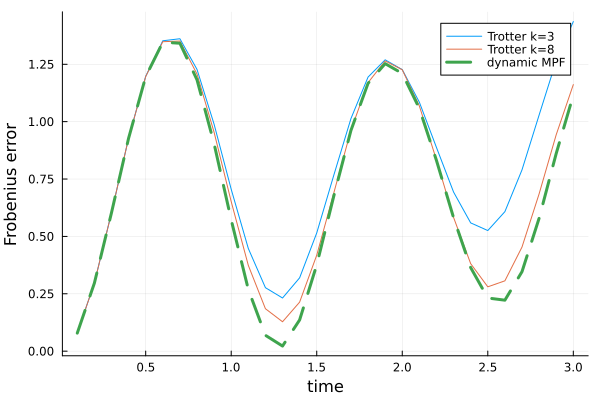

"c:\\Users\\Benjamin\\Desktop\\dmpf_dissipation-1\\figs\\frobenius_errors.pdf"

In [55]:
include("optimization_problem.jl")
times = 0.1:0.1:3.0
ks = [3, 8]

data = frobenius_data_vs_time(n, J, times, ks, sites, initial_state; cutoff=0.0, maxdim=1000)
plt = plot_frobenius_errors(data, ks)
display(plt)

mkpath("figs")
savefig(plt, "figs/frobenius_errors.png")
savefig(plt, "figs/frobenius_errors.pdf")

Another thing pending to do is the interpretation of each element of the MPOs $F_{ij}$.

In [3]:
for element in F_comp
    print(element.data)
end

ITensor[ITensor ord=3
Dim 1: (dim=2|id=337|"Qubit,Site,n=1")'
Dim 2: (dim=2|id=337|"Qubit,Site,n=1")
Dim 3: (dim=4|id=980|"Link,l=1")
NDTensors.Dense{ComplexF64, Vector{ComplexF64}}
 2×2×4
[:, :, 1] =
     -2.0000000000000178 + 2.569059257801529e-36im  2.0755245855328228e-27 - 9.321580665476716e-24im
 -3.5542490597466236e-22 - 4.208441875055254e-24im     -1.9999999999999902 - 6.205009367927508e-25im

[:, :, 2] =
  -4.840563669763393e-15 - 4.982140578458303e-15im   2.0537035197474474e-16 - 1.3213196499124505e-16im
 -1.0799055269208098e-16 + 1.4329662007287874e-16im   4.840563669763459e-15 + 4.982140578458371e-15im

[:, :, 3] =
   3.70388205818186e-18 + 1.0349511940873397e-17im   4.425868516762766e-16 + 1.8684692859036118e-16im
 -9.472109594561239e-17 + 4.3649634901417676e-16im  -3.703882058181911e-18 - 1.0349511940873538e-17im

[:, :, 4] =
 -1.008709223001384e-18 - 1.4021992128833829e-18im  -3.394144391117315e-17 + 7.71283928717483e-17im
  8.827871572197986e-17 + 2.0639775439086375e-17i

For this, we will contrast the tensor elements of the MPOs with the matrices obtained by computing $F_{ij}$ directly through matrix multiplication.

In [4]:
F_matrix = matrix_F(num_emitters, omega_m, omega_c, g, gamma, kappa, t, k)
using PrettyTables
for element in F_matrix
    pretty_table(real(round.(Matrix(element), digits=4)))
end

┌────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┐
│ Col. 1 │ Col. 2 │ Col. 3 │ Col. 4 │ Col. 5 │ Col. 6 │ Col. 7 │ Col. 8 │
├────────┼────────┼────────┼────────┼────────┼────────┼────────┼────────┤
│    1.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │
│    0.0 │    1.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │
│    0.0 │    0.0 │    1.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │
│    0.0 │    0.0 │    0.0 │    1.0 │    0.0 │    0.0 │    0.0 │    0.0 │
│    0.0 │    0.0 │    0.0 │    0.0 │    1.0 │    0.0 │    0.0 │    0.0 │
│    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    1.0 │    0.0 │    0.0 │
│    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    1.0 │    0.0 │
│    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    0.0 │    1.0 │
└────────┴────────┴────────┴────────┴────────┴────────┴────────┴────────┘
┌────────┬────────┬────────┬────────┬────────┬────────┬────────┬────────┐
│ Col. 1 │ Col. 2 │ Col. 3 │ Col. 4 │ 